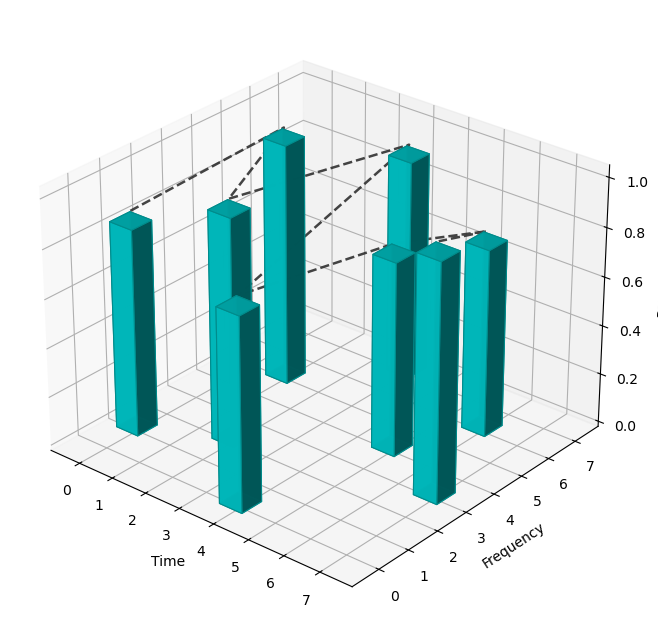

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

# ── 축 설정 ──────────────────────────────────────────────────────────
n_time  = 8   # Time 슬롯 수
n_freq  = 8   # Frequency 채널 수

time_slots = np.arange(n_time)
freq_bins  = np.arange(n_freq)

# ── 주파수 호핑 패턴 생성 ─────────────────────────────────────────────
hop_pattern = [1, 5, 2, 7, 0, 4, 6, 3]   # 각 시간 슬롯에서의 호핑 주파수

# ── 전력 행렬 생성 ────────────────────────────────────────────────────
power = np.zeros((n_time, n_freq))
for t, f in enumerate(hop_pattern):
    power[t, f] = np.random.uniform(0.75, 1.0)   # 호핑 위치만 전력 부여

fig = plt.figure(figsize=(13, 8))
ax  = fig.add_subplot(111, projection='3d')

# ── 막대 그리기 ───────────────────────────────────────────────────────
for t in range(n_time):
    for f in range(n_freq):
        h = power[t, f]
        if h > 0:
            ax.bar3d(t - 0.325, f - 0.325, 0, 0.65, 0.65, h,
                     color='#00CED1', alpha=0.95, edgecolor='#008B8B',
                     linewidth=0.8, shade=True)

# ── 호핑 경로 점선 연결 ───────────────────────────────────────────────
hop_z = [power[t, hop_pattern[t]] + 0.04 for t in time_slots]
ax.plot(time_slots, hop_pattern, hop_z,
        color='#303030', linewidth=1.8, linestyle='--', alpha=0.9)

ax.set_xlabel('Time');  ax.set_ylabel('Frequency');  ax.set_zlabel('Power')
ax.view_init(elev=28, azim=-50)
